In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import UCSmpl
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from os import listdir
from functools import partial

In [2]:
cases_ucs = pd.read_csv("cases_ucs_article.csv", index_col='case').iloc[:,:2]

In [ ]:
cases_ucs.at['AWS','Default Value'] = 1
cases_ucs.at['incentives_suffix','Default Value'] = 'obbba'
cases_ucs.at['GSw_TransRestrict','Default Value'] = 'transreg'
cases_ucs.at['GSw_TransInvMaxLongTerm','Default Value'] = 1.07
cases_ucs.at['convscen','Default Value'] = 'conv_ATB_2024_con_ccs_nuke'
cases_ucs.at['GSw_Clean_Air_Act','Default Value'] = 0
cases_ucs.at['GSw_EFS1_AllYearLoad','Default Value'] = "EER_Current_LowDC_UCS"

In [26]:
cases_ucs

,Description,Default Value
case,,
ignore,"0=run this case, 1=ignore this case",0
AWS,Switch for when running on AWS,1
timetype,Sequential or Intertemporal,seq
yearset_suffix,Set of years that are modeled,3yr
endyear,Last year to be modeled,2050
distpvscen,Setting for distpv scenario,stscen2023_mid_case_95_by_2050
batteryscen,Battery cost and performance characteristics,battery_ATB_2024_moderate
convscen,Conventional generators cost and performance c...,conv_ATB_2024_con_ccs_nuke
cspscen,CSP cost and performance characteristics,csp_ATB_2024_moderate


In [33]:
co2_caps = pd.read_csv("inputs/emission_constraints/co2_cap.csv", index_col='t')

In [34]:
co2_caps

,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,...,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050
t,,,,,,,,,,,,,,,,,,,,,
default,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,...,8.522570e+08,8.029727e+08,7.536885e+08,7.044042e+08,6.551200e+08,6.058357e+08,5.565515e+08,5.072672e+08,4.579830e+08,4.086987e+08
90_by_2050,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,...,3.864968e+08,3.700707e+08,3.546108e+08,3.381847e+08,3.217586e+08,3.062987e+08,2.898726e+08,2.734465e+08,2.579866e+08,2.415605e+08
95_by_2050,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,...,5.642853e+08,5.150070e+08,4.657286e+08,4.164503e+08,3.671720e+08,3.178936e+08,2.686153e+08,2.193369e+08,1.700586e+08,1.207802e+08
2050_linear,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,...,4.350000e+08,3.866667e+08,3.383333e+08,2.900000e+08,2.416667e+08,1.933333e+08,1.450000e+08,9.666667e+07,4.833333e+07,0.000000e+00
start2023_100pct2035,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
start2023_95pct2035_100pct2050,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,...,7.233666e+07,6.429925e+07,5.626185e+07,4.822444e+07,4.018703e+07,3.214963e+07,2.411222e+07,1.607481e+07,8.037407e+06,0.000000e+00
start2023_95pct2050,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,...,5.439105e+08,4.968716e+08,4.498328e+08,4.027940e+08,3.557552e+08,3.087164e+08,2.616776e+08,2.146387e+08,1.675999e+08,1.205611e+08
start2023_90pct2035_100pct2050,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,...,1.449363e+08,1.288323e+08,1.127282e+08,9.662420e+07,8.052017e+07,6.441613e+07,4.831210e+07,3.220807e+07,1.610403e+07,0.000000e+00
start2023_80pct2035_100pct2050,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,4.808220e+09,...,2.898726e+08,2.576645e+08,2.254565e+08,1.932484e+08,1.610403e+08,1.288323e+08,9.662420e+07,6.441613e+07,3.220807e+07,0.000000e+00


In [8]:
init_emit = 2411519000.0

<Axes: >

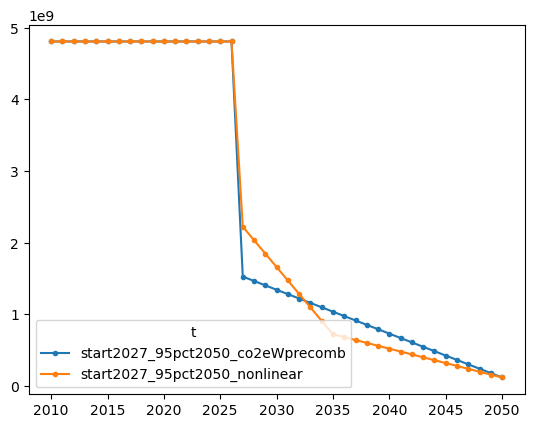

In [10]:
co2_caps.loc[['start2027_95pct2050_co2eWprecomb','start2027_95pct2050_nonlinear'], :].T.plot(marker='.')

[1.   0.96 0.84 0.64 0.36 0.  ]


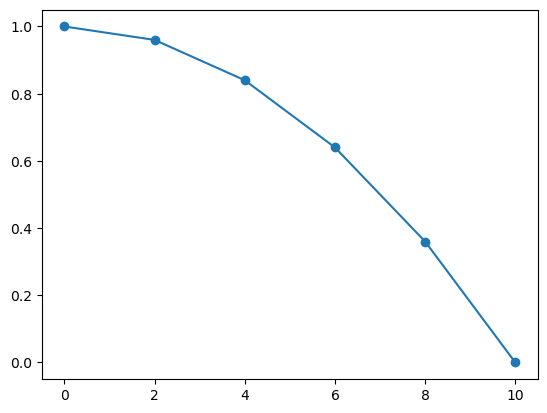

In [12]:
N = 6
x = np.linspace(0,10,N)
# percentages = (100-np.log(x))/x
pow = 2
percentages = np.round((100-(x**pow/(np.max(x)**(pow-2))))/100,2)
# percentages = 100-(x**2)

print(np.round(percentages,2))
plt.plot(x,percentages, marker='o')

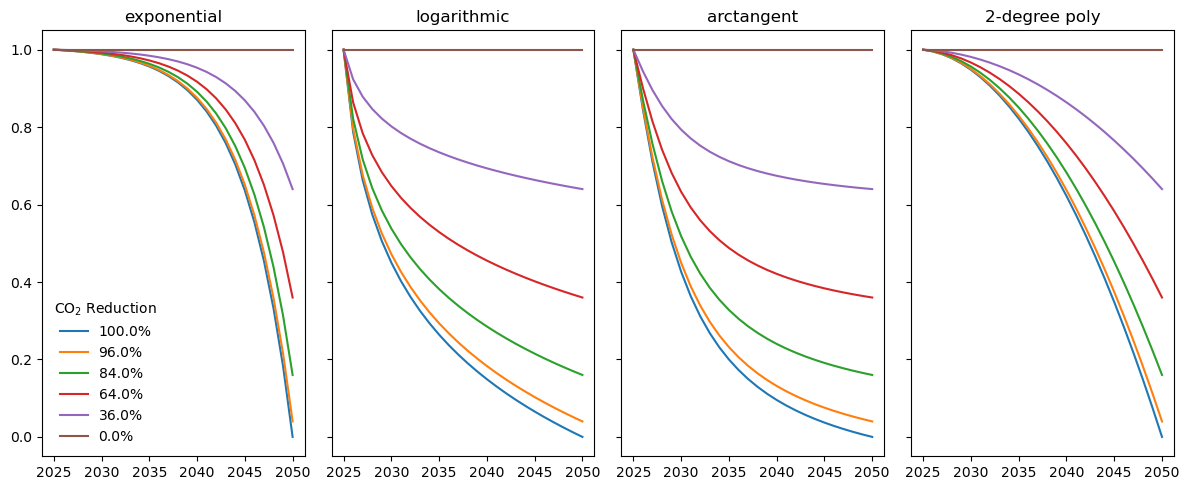

In [13]:
t = np.arange(2025, 2051,1)
t_sub = np.arange(1, len(t)+1, 1)
degree=2
func_list = [np.exp, np.log, np.arctan, partial(lambda x1,x2: x1**x2, x2=degree)]
func_names = ['exponential','logarithmic','arctangent','2-degree poly']
fig, ax = plt.subplots(1,len(func_list), sharey=True, figsize=(12,5))

for i,func in enumerate(func_list):
    for final_pct in percentages:
        y1 = 1-0
        y2 = 1-final_pct
        x1 = t_sub[0]
        x2 = t_sub[-1]
        k = 0.2

        # func = np.exp
        # func = np.log
        # func = np.arctan
        # degree = 1*1
        # func = partial(lambda x1,x2: x1**x2, x2=degree)
        a_num = (y2 - y1)
        a_den = (func(x2*k)-func(x1*k))
        a = a_num/a_den
        b = y1 - a*func(x1*k)

        ann_pct = a*func(k*t_sub)+b



        ax[i].plot(t, ann_pct, label=f'{final_pct*100}%')
        ax[i].set_title(func_names[i])
    # ax.set_yscale('log')
    ax[0].legend(title=r'CO$_2$ Reduction', frameon=False)
    plt.tight_layout()

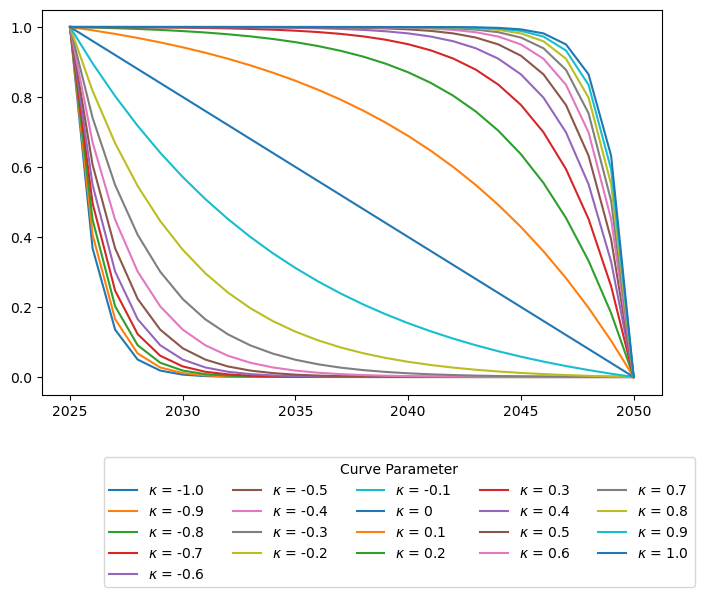

In [14]:
t = np.arange(2025, 2051,1)
t_sub = np.arange(1, len(t)+1, 1)
fig, ax = plt.subplots(1,1, sharey=True, figsize=(8,5))

kappas = np.round(np.linspace(-1,1,21),2)
for i,kap in enumerate(kappas):
    for final_pct in [1.0]:
    # for final_pct in percentages:
        y1 = 1-0
        y2 = 1-final_pct
        x1 = t_sub[0]
        x2 = t_sub[-1]
        k = np.round(kap,2)
        func = np.exp
        if np.isclose(kap, 0):
            degree = 1*1
            k = 1
            func = partial(lambda x1,x2: x1**x2, x2=degree)

        a_num = (y2 - y1)
        a_den = (func(x2*k)-func(x1*k))
        a = a_num/a_den
        b = y1 - a*func(x1*k)
        ann_pct = a*func(k*t_sub)+b

        if np.isclose(kap, 0):
            k = 0

        ax.plot(t, ann_pct, label=rf'$\kappa$ = {k}')
    # ax.set_yscale('log')
ax.legend(title=r'Curve Parameter', frameon=True, ncols=int(len(kappas)/4), loc=(0.1,-0.5))
# plt.tight_layout()

start2027_100pct2050_cave_15
start2027_96pct2050_cave_15
start2027_84pct2050_cave_15
start2027_64pct2050_cave_15
start2027_36pct2050_cave_15
start2027_0pct2050_cave_15


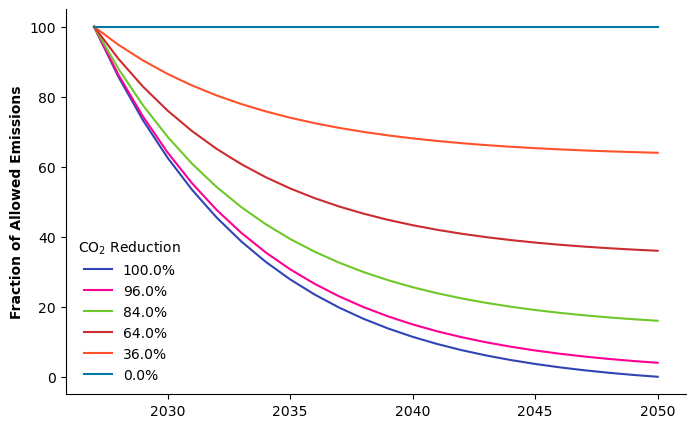

In [27]:
t = np.arange(2027, 2051,1)
t_sub = np.arange(1, len(t)+1, 1)

names_list = []
with plt.style.context("ucs_light"):
    fig, ax = plt.subplots(1,1, sharey=True, figsize=(8,5))

    # kappas = [-0.2]
    kappas = [-0.15]
    for i,kap in enumerate(kappas):
        # for final_pct in [1.0]:
        for final_pct in percentages:
            y1 = 1-0
            y2 = 1-final_pct
            x1 = t_sub[0]
            x2 = t_sub[-1]
            k = np.round(kap,2)
            func = np.exp
            if np.isclose(kap, 0):
                degree = 1*1
                k = 1
                func = partial(lambda x1,x2: x1**x2, x2=degree)

            a_num = (y2 - y1)
            a_den = (func(x2*k)-func(x1*k))
            a = a_num/a_den
            b = y1 - a*func(x1*k)
            ann_pct = a*func(k*t_sub)+b

            if np.isclose(kap, 0):
                k = 0

            # add scenario
            name = f"start2027_{int(final_pct*100)}pct2050_cave_{int(100*np.abs(k))}"
            names_list.append(name)
            print(name)
            co2_caps.loc[name, :] = co2_caps.loc['start2027_95pct2050_nonlinear', :]
            co2_caps.loc[name, '2027':] = np.round(ann_pct,4)*init_emit

            # add scenario to cases
            case_name = f'CP_LowTrans_LowDC_{int(final_pct*100)}pct2050'
            cases_ucs[case_name] = ''
            cases_ucs.at['GSw_AnnualCap', case_name] = 1
            cases_ucs.at['GSw_AnnualCapScen', case_name] = name




            ax.plot(t, (ann_pct*100), label=rf'{final_pct*100}%')
        # ax.set_yscale('log')
    ax.legend(title=r'CO$_2$ Reduction', frameon=False, ncols=int(len(percentages)/4))
    ax.set_ylabel("Fraction of Allowed Emissions")

In [28]:
cases_ucs

,Description,Default Value,CP_LowTrans_LowDC_100pct2050,CP_LowTrans_LowDC_96pct2050,CP_LowTrans_LowDC_84pct2050,CP_LowTrans_LowDC_64pct2050,CP_LowTrans_LowDC_36pct2050,CP_LowTrans_LowDC_0pct2050
case,,,,,,,,
ignore,"0=run this case, 1=ignore this case",0,,,,,,
AWS,Switch for when running on AWS,1,,,,,,
timetype,Sequential or Intertemporal,seq,,,,,,
yearset_suffix,Set of years that are modeled,3yr,,,,,,
endyear,Last year to be modeled,2050,,,,,,
distpvscen,Setting for distpv scenario,stscen2023_mid_case_95_by_2050,,,,,,
batteryscen,Battery cost and performance characteristics,battery_ATB_2024_moderate,,,,,,
convscen,Conventional generators cost and performance c...,conv_ATB_2024_con_ccs_nuke,,,,,,
cspscen,CSP cost and performance characteristics,csp_ATB_2024_moderate,,,,,,


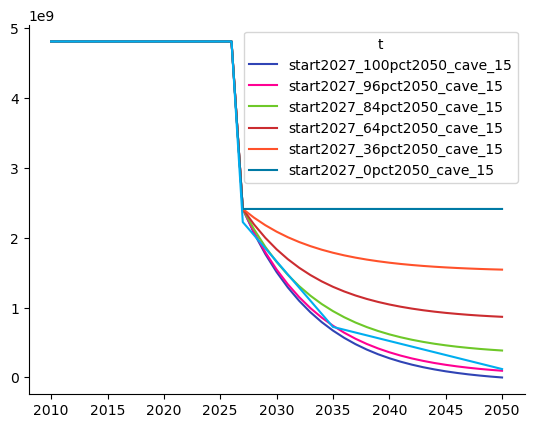

In [23]:
with plt.style.context("ucs_light"):
    fig, ax = plt.subplots()
    co2_caps.iloc[-6:, :].T.plot(ax=ax)
    co2_caps.loc['start2027_95pct2050_nonlinear', :].T.plot(ax=ax)

In [31]:
cases_ucs.to_csv("cases_ucs_article.csv")

In [32]:
co2_caps.to_csv("inputs/emission_constraints/co2_cap.csv")

In [ ]:
cases = pd.read_csv("cases.csv", index_col=0)

In [ ]:
cases.T['GSw_AnnualCapScen']

Description      Scenario for CO2 cap pathway (see inputs\emiss...
Choices                                                        NaN
Default Value                                              default
Ref                                                            NaN
Name: GSw_AnnualCapScen, dtype: object